# PINN for Transient 1D Heat Conduction

This notebook solves the transient one-dimensional heat equation

\[ \frac{\partial T}{\partial t} = \alpha\frac{\partial^2T}{\partial x^2}, \qquad 0\leq x\leq1,\quad 0\leq t\leq1 \]

with

\[ T(0,t)=T(1,t)=0 \]

and initial condition

\[ T(x,0)=\sin(\pi x). \]

For \(\alpha=0.1\), the analytical solution is

\[ T(x,t) = \sin(\pi x)e^{-\alpha\pi^2t}. \]

The PINN is trained by simultaneously minimizing the PDE residual,
boundary-condition loss, and initial-condition loss.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


# ==== Reproducibility ==========================================
torch.manual_seed(43)


# ==== INTERIOR COLLOCATION POINTS ==============================

n_colloc = 1000

x_colloc = torch.rand(n_colloc, 1)
x_colloc.requires_grad_(True)

t_colloc = torch.rand(n_colloc, 1)
t_colloc.requires_grad_(True)

xt_colloc = torch.cat((x_colloc, t_colloc), dim=1)


# ==== BOUNDARY POINTS =========================================

t_bc    = torch.linspace(0,1,100).view(-1,1)
x_left_bc  = torch.zeros_like(t_bc)
x_right_bc = torch.ones_like(t_bc)

xt_left     = torch.cat((x_left_bc,  t_bc), dim=1)
xt_right    = torch.cat((x_right_bc, t_bc), dim=1)


# ==== INITIAL CONDITION POINTS ================================

x_ic    = torch.linspace(0,1,100).view(-1,1)
t_ic    = torch.zeros_like(x_ic)
xt_ic   = torch.cat((x_ic, t_ic), dim=1)

T_ic_exact = torch.sin(torch.pi * x_ic)


# ==== NEURAL NETWORK ==========================================
model = nn.Sequential(
    nn.Linear(2, 32),
    nn.Tanh(),
    nn.Linear(32,32),
    nn.Tanh(),
    nn.Linear(32,1)
)


# ==== Optimizer ===============================================
optimizer = torch.optim.Adam(
    model.parameters(),
    lr = 0.01
)


# ---- Reduce learning rate during training -----------------------
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=1000,
    gamma=0.5
)


## PINN Training

In [2]:
n_epochs = 3000

a = 0.1

for epoch in range(n_epochs):

    # ---- PDE LOSS -------------------------------------
    T = model(xt_colloc)

    dT_dx = torch.autograd.grad(
        T, x_colloc,
        grad_outputs=torch.ones_like(T),
        create_graph=True
    )[0]

    d2T_dx2 = torch.autograd.grad(
        dT_dx, x_colloc,
        grad_outputs=torch.ones_like(dT_dx),
        create_graph=True
    )[0]

    dT_dt = torch.autograd.grad(
        T, t_colloc,
        grad_outputs=torch.ones_like(T),
        create_graph=True
    )[0]

    pde_residual =  dT_dt - a*d2T_dx2
    loss_pde    = torch.mean(pde_residual**2)


    # ---- BC LOSS --------------------------------------
    T_left  = model(xt_left)
    T_right = model(xt_right)

    loss_left   = torch.mean((T_left - 0.0)**2)
    loss_right  = torch.mean((T_right - 0.0)**2)

    loss_bc = loss_left + loss_right


    # ---- IC LOSS ---------------------------------------
    T_ic    = model(xt_ic)
    loss_ic = torch.mean((T_ic - T_ic_exact)**2)


    # ---- TOTAL LOSS ------------------------------------
    loss = loss_pde + loss_bc + loss_ic


    # ---- Update NN parameters --------------------------
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()


    # ---- Display training progress ---------------------
    if epoch % 300 == 0:
        print(
            f"Epoch {epoch:4d} | "
            f"PDE loss = {loss_pde.item():.6f} | "
            f"BC loss = {loss_bc.item():.6f} | "
            f"Initial loss = {loss_ic.item():.6f} | "
            f"Total loss = {loss.item():.6f}"
        )


Epoch    0 | PDE loss = 0.002195 | BC loss = 0.153352 | Initial loss = 0.947475 | Total loss = 1.103023
Epoch  300 | PDE loss = 0.000321 | BC loss = 0.000043 | Initial loss = 0.000008 | Total loss = 0.000372
Epoch  600 | PDE loss = 0.000099 | BC loss = 0.000026 | Initial loss = 0.000002 | Total loss = 0.000127
Epoch  900 | PDE loss = 0.000065 | BC loss = 0.000016 | Initial loss = 0.000003 | Total loss = 0.000083
Epoch 1200 | PDE loss = 0.000056 | BC loss = 0.000014 | Initial loss = 0.000003 | Total loss = 0.000073
Epoch 1500 | PDE loss = 0.000040 | BC loss = 0.000012 | Initial loss = 0.000003 | Total loss = 0.000054
Epoch 1800 | PDE loss = 0.000027 | BC loss = 0.000009 | Initial loss = 0.000003 | Total loss = 0.000040
Epoch 2100 | PDE loss = 0.000020 | BC loss = 0.000008 | Initial loss = 0.000003 | Total loss = 0.000031
Epoch 2400 | PDE loss = 0.000017 | BC loss = 0.000007 | Initial loss = 0.000003 | Total loss = 0.000026
Epoch 2700 | PDE loss = 0.000014 | BC loss = 0.000006 | Initial 

## Numerical Evaluation

In [3]:
x_check = torch.linspace(0,1,5).view(-1,1)
t_check = torch.linspace(0,1,5).view(-1,1)

xt_check = torch.cat((x_check,t_check), dim=1)

model.eval()

with torch.no_grad():
    T_pred = model(xt_check)

print("\nPINN vs analytical solution\n")
for i in range(len(xt_check)):
    x_val       = x_check[i].item()
    t_val       = t_check[i].item()
    pinn_val    = T_pred[i].item()
    exact_val   = (
        torch.sin(torch.pi*x_check[i])
        * torch.exp(-a*(torch.pi**2)*t_check[i])
    ).item()

    print(
        f"x         = {x_val:.2f}  | "
        f"PINN      = {pinn_val:.4f}  | "
        f"Exact     = {exact_val:.4f}  | "
    )


PINN vs analytical solution

x         = 0.00  | PINN      = -0.0010  | Exact     = 0.0000  | 
x         = 0.25  | PINN      = 0.5520  | Exact     = 0.5525  | 
x         = 0.50  | PINN      = 0.6102  | Exact     = 0.6105  | 
x         = 0.75  | PINN      = 0.3378  | Exact     = 0.3373  | 
x         = 1.00  | PINN      = -0.0042  | Exact     = -0.0000  | 


## Temperature Evolution

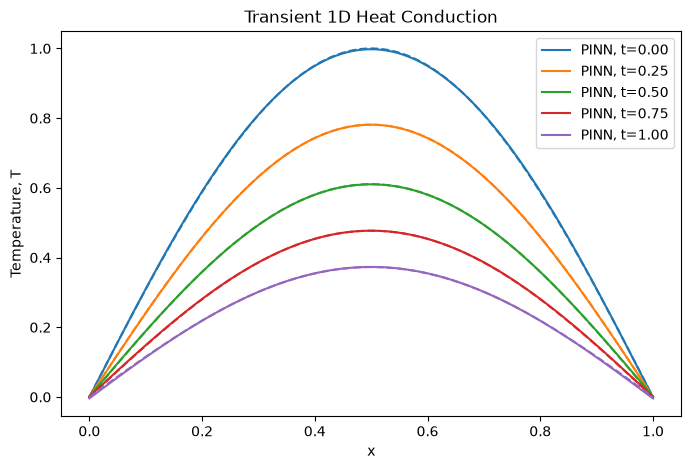

In [4]:
x_plot  = torch.linspace(0, 1, 200).view(-1, 1)
times   = [0.0, 0.25, 0.50, 0.75, 1.0]

model.eval()
plt.figure(figsize=(8, 5))

with torch.no_grad():

    for t_val in times:

        # Same time value for every x location
        t_plot = torch.full_like(x_plot, t_val)

        # NN input: [x, t]
        xt_plot = torch.cat(
            (x_plot, t_plot),
            dim=1
        )

        # PINN solution
        T_pinn = model(xt_plot)

        # Analytical solution
        T_exact = (
            torch.sin(torch.pi * x_plot)
            * torch.exp(-a * torch.pi**2 * t_plot)
        )

        # Plot PINN
        line = plt.plot(
            x_plot.numpy(),
            T_pinn.numpy(),
            label=f"PINN, t={t_val:.2f}"
        )

        # Analytical solution with same color
        plt.plot(
            x_plot.numpy(),
            T_exact.numpy(),
            "--",
            color=line[0].get_color()
        )

plt.xlabel("x")
plt.ylabel("Temperature, T")
plt.title("Transient 1D Heat Conduction")
plt.legend()
plt.show()

## Space-Time Temperature Field

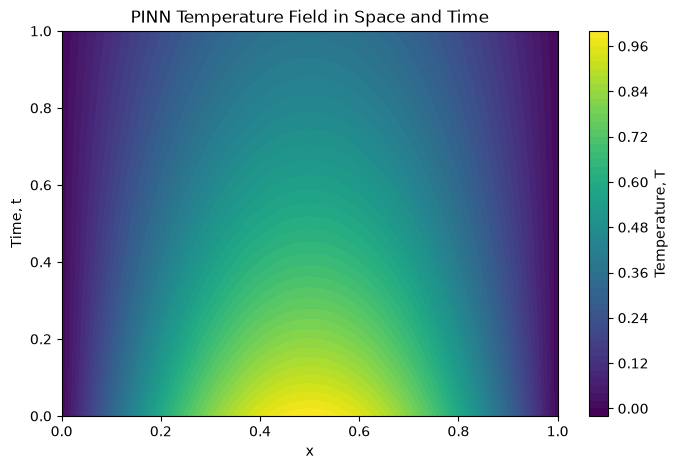

In [5]:
x_values = torch.linspace(0, 1, 100)
t_values = torch.linspace(0, 1, 100)

# Every combination of x and t
T_grid, X_grid = torch.meshgrid(
    t_values,
    x_values,
    indexing="ij"
)

x_flat = X_grid.reshape(-1, 1)
t_flat = T_grid.reshape(-1, 1)

xt_grid = torch.cat(
    (x_flat, t_flat),
    dim=1
)

model.eval()
with torch.no_grad():
    temperature = model(xt_grid)

temperature = temperature.reshape(100, 100)

plt.figure(figsize=(8, 5))

contour = plt.contourf(
    X_grid.numpy(),
    T_grid.numpy(),
    temperature.numpy(),
    levels=50
)

plt.colorbar(
    contour,
    label="Temperature, T"
)

plt.xlabel("x")
plt.ylabel("Time, t")
plt.title("PINN Temperature Field in Space and Time")

plt.show()

## Absolute Error

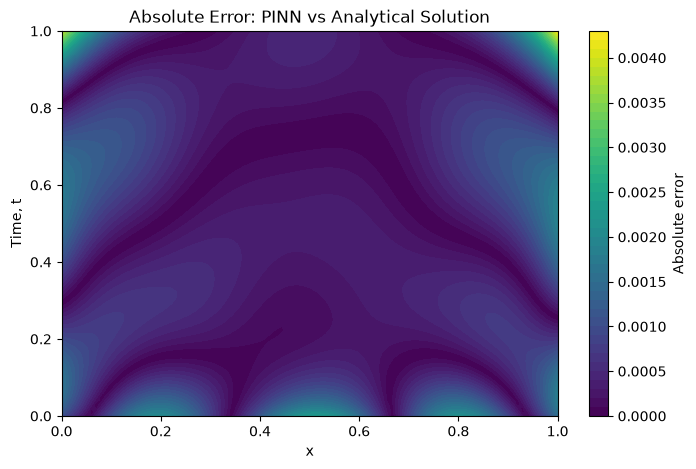

In [6]:
T_exact_grid = (
    torch.sin(torch.pi * X_grid)
    * torch.exp(-a * torch.pi**2 * T_grid)
)

absolute_error = torch.abs(
    temperature - T_exact_grid
)

plt.figure(figsize=(8, 5))
contour = plt.contourf(
    X_grid.numpy(),
    T_grid.numpy(),
    absolute_error.numpy(),
    levels=50
)

plt.colorbar(
    contour,
    label="Absolute error"
)

plt.xlabel("x")
plt.ylabel("Time, t")
plt.title("Absolute Error: PINN vs Analytical Solution")

plt.show()